In [192]:
import pandas as pd
import numpy as np

In [193]:
df = pd.read_csv("master_data_2020.csv")
df = df[~df["presvote20post"].isna()]

treatment = "untrustworthy_flag"
vote = df["presvote20post"].astype(str).str.strip()

df["voted_biden_2020"] = (vote == "Joe Biden").astype(int)
df["voted_trump_2020"] = (vote == "Donald Trump").astype(int)
df["turnout_2020_binary"] = (
    ~vote.str.contains("did not vote|skipped|__na__", case=False, na=True)
).astype(int)

outcomes = {
    "2020 Turnout": "turnout_2020_binary",
    "Voted for Biden": "voted_biden_2020",
    "Voted for Trump": "voted_trump_2020",
}

# Digital literacy: average of the first numeric token in each tf_* item
tf_cols = ["tf_adv", "tf_pdf", "tf_spy", "tf_wiki", "tf_cache", "tf_phishing"]
df["digital_literacy_index"] = df[tf_cols].map(
    lambda v: int(str(v).strip().split()[0])
    if pd.notna(v) and str(v).strip().split()[0].isdigit() else np.nan
).mean(axis=1)

df["ideo5_linear"] = df["ideo5"].map(
    {"Very liberal": 1, "Liberal": 2, "Moderate": 3, "Conservative": 4, "Very conservative": 5})
df["pid7_linear"] = df["pid7"].map(
    {"Strong Democrat": 1, "Not very strong Democrat": 2, "Lean Democrat": 3, "Independent": 4,
     "Lean Republican": 5, "Not very strong Republican": 6, "Strong Republican": 7})
df["socmed_use_linear"] = df["socmed_use"].astype(str).str.strip().map(
    {"Less than 10 minutes per day": 1, "10–30 minutes per day": 2, "31–60 minutes per day": 3,
     "1–2 hours per day": 4, "2–3 hours per day": 5, "More than 3 hours per day": 6})
df["newsint_linear"] = df["newsint"].astype(str).str.strip().map(
    {"Hardly at all": 1, "Only now and then": 2, "Some of the time": 3, "Most of the time": 4})
df["intuse_linear"] = df["intuse"].astype(str).str.strip().map(
    {"Less often": 1, "A few times a week": 2, "About once a day": 3, "Several times a day": 4}).fillna(3)


def condense_2016_vote(val):
    s = str(val).strip()
    if s in ("Hillary Clinton", "Donald Trump"):
        return s
    if pd.isna(val) or s in ("__NA__", "nan", "Did not vote", "Did not vote for President"):
        return "Did Not Vote"
    return "Other"


df["presvote16post_condensed"] = df["presvote16post"].apply(condense_2016_vote)

categorical_covariates = ["race4", "educ4", "region", "presvote16post_condensed"]
linear_features = ["ideo5_linear", "pid7_linear", "socmed_use_linear", "newsint_linear", "intuse_linear"]
engineered_continuous = ["digital_literacy_index"]
core_cols = [treatment] + list(outcomes.values()) + ["age", "female"]

df_clean = df[core_cols + engineered_continuous + linear_features + categorical_covariates].dropna().copy()

baselines_to_drop = [
    "presvote16post_condensed_Donald Trump", "race4_White",
    "educ4_College grad", "region_Midwest",
]
X_matrix = pd.get_dummies(
    df_clean[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates, drop_first=False, dtype=int,
).drop(columns=baselines_to_drop, errors="ignore")

W = df_clean[treatment].astype(int).values
Y_turnout = df_clean[outcomes["2020 Turnout"]].astype(int).values
Y_biden = df_clean[outcomes["Voted for Biden"]].astype(int).values
Y_trump = df_clean[outcomes["Voted for Trump"]].astype(int).values

In [ ]:
raw_post_weights = df.loc[df_clean.index, "weight_post"].fillna(1.0).values
lo, hi = np.percentile(raw_post_weights, [5, 95])
survey_weights = np.clip(raw_post_weights, lo, hi)
survey_weights = survey_weights / survey_weights.mean()

In [195]:
df.columns.tolist()

['consent',
 'encountered_fakenews1',
 'fakenews_pctg1',
 'fnews_story1',
 'fnews_story2',
 'fnews_story3',
 'fnews_story4',
 'fnews_story5',
 'fnews_story6',
 'fnews_story7',
 'fnews_story8',
 'fnews_story9',
 'fnews_story0',
 'certainty_nofakenews1',
 'respondent_stories_1',
 'respondent_stories_2',
 'respondent_stories_3',
 'respondent_stories_4',
 'respondent_stories_5',
 'respondent_stories_6',
 'respondent_stories_7',
 'respondent_stories_8',
 'respondent_stories_9',
 'respondent_stories_10',
 'fnews_story1_source',
 'fnews_story1_recognize',
 'fnews_story2_source',
 'fnews_story2_recognize',
 'fnews_story3_source',
 'fnews_story3_recognize',
 'fnews_story4_source',
 'fnews_story4_recognize',
 'fnews_story5_source',
 'fnews_story5_recognize',
 'fnews_story6_source',
 'fnews_story6_recognize',
 'fnews_story7_source',
 'fnews_story7_recognize',
 'fnews_story8_source',
 'fnews_story8_recognize',
 'fnews_story9_source',
 'fnews_story9_recognize',
 'fnews_story0_source',
 'fnews_story

In [196]:
df["encountered_fakenews1"].value_counts(normalize=True)

encountered_fakenews1
A fair amount                           0.434650
Not very much                           0.243161
A great deal                            0.236069
I have not encountered any fake news    0.046606
Nearly all news I see is fake           0.039514
Name: proportion, dtype: float64

In [197]:
df['encountered_fakenews1_post'].value_counts(normalize=True)

encountered_fakenews1_post
A fair amount                           0.410516
Not very much                           0.265925
A great deal                            0.200202
I have not encountered any fake news    0.069767
Nearly all news I see is fake           0.053589
Name: proportion, dtype: float64

In [ ]:
import scipy.stats as stats
import statsmodels.api as sm

X_const = sm.add_constant(X_matrix)
N = len(W)

prop = sm.GLM(W, X_const, family=sm.families.Binomial(),
              freq_weights=survey_weights).fit(maxiter=1000)
e_hat = np.clip(np.asarray(prop.predict(X_const)), 0.05, 0.95)

param_aipw_results = {}
for name, Y in {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}.items():
    m1 = sm.GLM(Y[W == 1], X_const[W == 1], family=sm.families.Binomial(),
                freq_weights=survey_weights[W == 1]).fit(maxiter=1000)
    m0 = sm.GLM(Y[W == 0], X_const[W == 0], family=sm.families.Binomial(),
                freq_weights=survey_weights[W == 0]).fit(maxiter=1000)
    mu1, mu0 = np.asarray(m1.predict(X_const)), np.asarray(m0.predict(X_const))

    psi = (mu1 - mu0) + W * (Y - mu1) / e_hat - (1 - W) * (Y - mu0) / (1 - e_hat)
    ate = np.average(psi, weights=survey_weights)
    se = np.sqrt(np.sum((survey_weights * (psi - ate)) ** 2) / N ** 2)
    p = 2 * (1 - stats.norm.cdf(abs(ate / se)))
    param_aipw_results[name] = dict(ate=ate, se=se, ci_lo=ate - 1.96 * se, ci_hi=ate + 1.96 * se, p=p)

pd.DataFrame(param_aipw_results).T

,ate,se,ci_lo,ci_hi,p
Voted for Biden,-0.021176,0.016995,-0.054486,0.012134,0.212765
Voted for Trump,0.026354,0.019944,-0.012736,0.065443,0.186361


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = X_matrix.values
N = len(W)
np.random.seed(42)
folds = np.array_split(np.random.permutation(N), 5)


def rf_fit(X_tr, y_tr, w):
    return RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1
    ).fit(X_tr, y_tr, sample_weight=w / w.mean())


# Cross-fitted propensity scores
e_hat_rf = np.zeros(N)
for val in folds:
    tr = np.setdiff1d(np.arange(N), val)
    e_hat_rf[val] = rf_fit(X[tr], W[tr], survey_weights[tr]).predict_proba(X[val])[:, 1]

# Cross-fitted outcome models
mu_1_rf, mu_0_rf = {}, {}
for name, Y in {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}.items():
    m1, m0 = np.zeros(N), np.zeros(N)
    for val in folds:
        tr = np.setdiff1d(np.arange(N), val)
        w, t, c = survey_weights[tr], W[tr] == 1, W[tr] == 0
        m1[val] = rf_fit(X[tr][t], Y[tr][t], w[t]).predict_proba(X[val])[:, 1]
        m0[val] = rf_fit(X[tr][c], Y[tr][c], w[c]).predict_proba(X[val])[:, 1]
    mu_1_rf[name], mu_0_rf[name] = m1, m0


def aipw_summary(Y, e, mu1, mu0, w):
    e = np.clip(e, 0.05, 0.95)
    psi = (mu1 - mu0) + W * (Y - mu1) / e - (1 - W) * (Y - mu0) / (1 - e)
    ate = np.average(psi, weights=w)
    se = np.sqrt(np.sum((w * (psi - ate)) ** 2) / len(w) ** 2)
    return dict(ate=ate, se=se, p=2 * (1 - stats.norm.cdf(abs(ate / se))),
                ci_lo=ate - 1.96 * se, ci_hi=ate + 1.96 * se)


rf_aipw_results = {
    name: aipw_summary(Y, e_hat_rf, mu_1_rf[name], mu_0_rf[name], survey_weights)
    for name, Y in {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}.items()
}
pd.DataFrame(rf_aipw_results).T

,ate,se,p,ci_lo,ci_hi
Voted for Biden,-0.036450,0.022111,0.099253,-0.079787,0.006888
Voted for Trump,0.065362,0.025277,0.009714,0.015820,0.114905


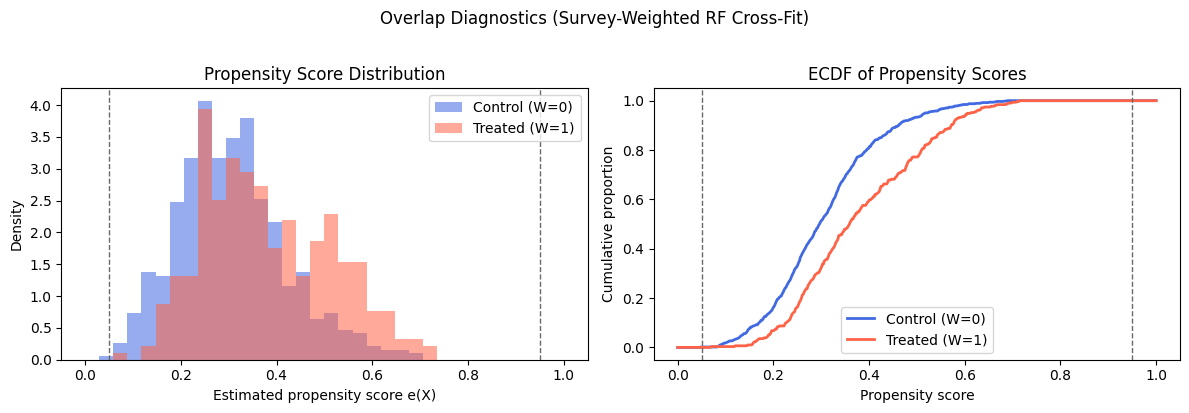

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# Overlap
tr, ct = W == 1, W == 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, 1, 35)
ax1.hist(e_hat_rf[ct], bins=bins, alpha=0.55, color="royalblue", density=True, label="Control (W=0)")
ax1.hist(e_hat_rf[tr], bins=bins, alpha=0.55, color="tomato", density=True, label="Treated (W=1)")
for x in (0.05, 0.95):
    ax1.axvline(x, color="dimgray", ls="--", lw=1)
ax1.set(xlabel="Estimated propensity score e(X)", ylabel="Density", title="Propensity Score Distribution")
ax1.legend()

grid = np.linspace(0, 1, 500)
ax2.plot(grid, ECDF(e_hat_rf[ct])(grid), color="royalblue", lw=2, label="Control (W=0)")
ax2.plot(grid, ECDF(e_hat_rf[tr])(grid), color="tomato", lw=2, label="Treated (W=1)")
for x in (0.05, 0.95):
    ax2.axvline(x, color="dimgray", ls="--", lw=1)
ax2.set(xlabel="Propensity score", ylabel="Cumulative proportion", title="ECDF of Propensity Scores")
ax2.legend()

fig.suptitle("Overlap Diagnostics (Survey-Weighted RF Cross-Fit)", y=1.02)
fig.tight_layout()
plt.show()

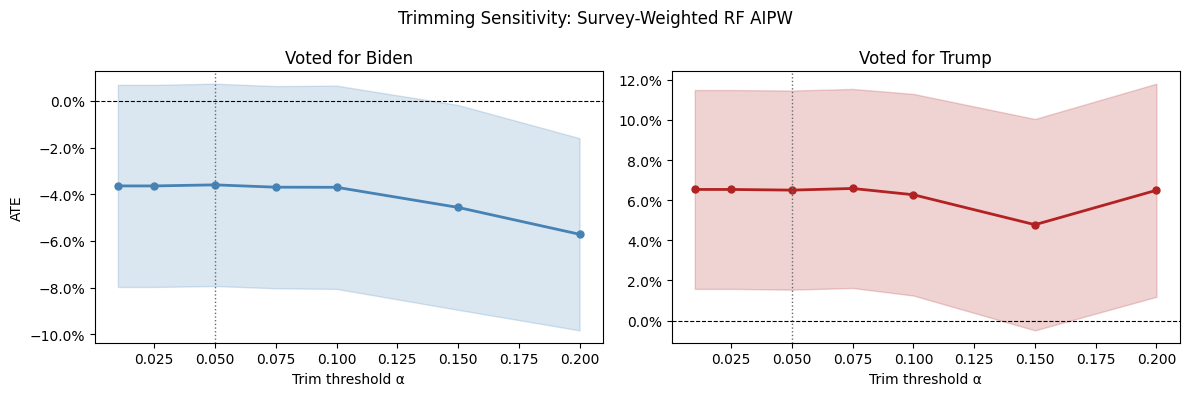

,outcome,p0,ate,E_value,E_value_CI
0,Voted for Biden,0.540,-0.036,1.348,1.131
1,Voted for Trump,0.361,0.065,1.641,1.254


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

outcome_arrs = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}


def wate_se(psi, w):
    w = w / w.mean()
    ate = np.average(psi, weights=w)
    se = np.sqrt(np.sum((w * (psi - ate)) ** 2) / len(psi) ** 2)
    return ate, se


# Trimming sensitivity
alphas = [0.01, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20]
trim_res = {name: {"ate": [], "ci_lo": [], "ci_hi": []} for name in outcome_arrs}

for a in alphas:
    keep = (e_hat_rf >= a) & (e_hat_rf <= 1 - a)
    e_k, W_k, w_k = np.clip(e_hat_rf[keep], a, 1 - a), W[keep], survey_weights[keep]
    for name, Y in outcome_arrs.items():
        Y_k, mu1_k, mu0_k = Y[keep], mu_1_rf[name][keep], mu_0_rf[name][keep]
        psi = (mu1_k - mu0_k) + W_k * (Y_k - mu1_k) / e_k - (1 - W_k) * (Y_k - mu0_k) / (1 - e_k)
        ate, se = wate_se(psi, w_k)
        trim_res[name]["ate"].append(ate)
        trim_res[name]["ci_lo"].append(ate - 1.96 * se)
        trim_res[name]["ci_hi"].append(ate + 1.96 * se)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = {"Voted for Biden": "steelblue", "Voted for Trump": "firebrick"}
for ax, name in zip(axes, trim_res):
    r = trim_res[name]
    ax.fill_between(alphas, r["ci_lo"], r["ci_hi"], alpha=0.2, color=palette[name])
    ax.plot(alphas, r["ate"], "o-", color=palette[name], lw=2, ms=5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.axvline(0.05, color="dimgray", ls=":", lw=1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
    ax.set(xlabel="Trim threshold α", title=name)
axes[0].set_ylabel("ATE")
fig.suptitle("Trimming Sensitivity: Survey-Weighted RF AIPW")
fig.tight_layout()
plt.show()


# E-values
def evalue(rr):
    rr = max(rr, 1.0)
    return rr + np.sqrt(rr * (rr - 1))


def rr_from_rd(rd, p0):
    p1 = np.clip(p0 + rd, 1e-6, 1 - 1e-6)
    rr = p1 / p0
    return rr if rr >= 1 else 1 / rr


base = alphas.index(0.05)
rows = []
for name, Y in outcome_arrs.items():
    p0 = np.average(Y[W == 0], weights=survey_weights[W == 0])
    ate = trim_res[name]["ate"][base]
    bound = trim_res[name]["ci_hi"][base] if ate < 0 else trim_res[name]["ci_lo"][base]
    rows.append({
        "outcome": name, "p0": round(p0, 3), "ate": round(ate, 4),
        "E_value": round(evalue(rr_from_rd(ate, p0)), 3),
        "E_value_CI": round(evalue(rr_from_rd(bound, p0)), 3) if abs(bound) > 1e-3 else 1.0,
    })
pd.DataFrame(rows)

In [ ]:
# Negative-control outcome
df["voted_trump_2016"] = (df["presvote16post"].astype(str).str.strip() == "Donald Trump").astype(int)

noc_cats = ["race4", "educ4", "region"]
noc_cols = [treatment, "voted_trump_2016", "age", "female"] + engineered_continuous + linear_features + noc_cats
df_noc = df[noc_cols].dropna().copy()

X_noc = pd.get_dummies(
    df_noc[["age", "female"] + engineered_continuous + linear_features + noc_cats],
    columns=noc_cats, drop_first=False, dtype=int,
).drop(columns=["race4_White", "educ4_College grad", "region_Midwest"], errors="ignore").values

W_noc = df_noc[treatment].astype(int).values
Y_noc = df_noc["voted_trump_2016"].astype(int).values
N_noc = len(W_noc)

raw = df.loc[df_noc.index, "weight_post"].fillna(1.0).values
lo, hi = np.percentile(raw, [5, 95])
w_noc = np.clip(raw, lo, hi)
w_noc = w_noc / w_noc.mean()

np.random.seed(42)
folds_noc = np.array_split(np.random.permutation(N_noc), 5)
e_noc = np.zeros(N_noc)
mu1 = np.zeros(N_noc)
mu0 = np.zeros(N_noc)
for val in folds_noc:
    tr = np.setdiff1d(np.arange(N_noc), val)
    w, t, c = w_noc[tr], W_noc[tr] == 1, W_noc[tr] == 0
    e_noc[val] = rf_fit(X_noc[tr], W_noc[tr], w).predict_proba(X_noc[val])[:, 1]
    mu1[val] = rf_fit(X_noc[tr][t], Y_noc[tr][t], w[t]).predict_proba(X_noc[val])[:, 1]
    mu0[val] = rf_fit(X_noc[tr][c], Y_noc[tr][c], w[c]).predict_proba(X_noc[val])[:, 1]

e_noc = np.clip(e_noc, 0.05, 0.95)
psi = (mu1 - mu0) + W_noc * (Y_noc - mu1) / e_noc - (1 - W_noc) * (Y_noc - mu0) / (1 - e_noc)
ate_noc_rf = np.average(psi, weights=w_noc)
se_noc_rf = np.sqrt(np.sum((w_noc * (psi - ate_noc_rf)) ** 2) / N_noc ** 2)
p_noc_rf = 2 * (1 - stats.norm.cdf(abs(ate_noc_rf / se_noc_rf)))
ci_lo_noc, ci_hi_noc = ate_noc_rf - 1.96 * se_noc_rf, ate_noc_rf + 1.96 * se_noc_rf

# Calibrate 2020
se_biden_cal = np.sqrt(rf_aipw_results["Voted for Biden"]["se"] ** 2 + se_noc_rf ** 2)
se_trump_cal = np.sqrt(rf_aipw_results["Voted for Trump"]["se"] ** 2 + se_noc_rf ** 2)
ate_biden_cal = rf_aipw_results["Voted for Biden"]["ate"] - ate_noc_rf
ate_trump_cal = rf_aipw_results["Voted for Trump"]["ate"] - ate_noc_rf

pd.DataFrame({
    "NOC (2016 Trump)": dict(ate=ate_noc_rf, ci_lo=ci_lo_noc, ci_hi=ci_hi_noc, p=p_noc_rf),
    "Biden (calibrated)": dict(ate=ate_biden_cal, ci_lo=ate_biden_cal - 1.96 * se_biden_cal,
                               ci_hi=ate_biden_cal + 1.96 * se_biden_cal, p=np.nan),
    "Trump (calibrated)": dict(ate=ate_trump_cal, ci_lo=ate_trump_cal - 1.96 * se_trump_cal,
                               ci_hi=ate_trump_cal + 1.96 * se_trump_cal, p=np.nan),
}).T

,ate,ci_lo,ci_hi,p
NOC (2016 Trump),0.012444,-0.045610,0.070499,0.674387
Biden (calibrated),-0.048894,-0.121341,0.023553,NaN
Trump (calibrated),0.052918,-0.023402,0.129239,NaN


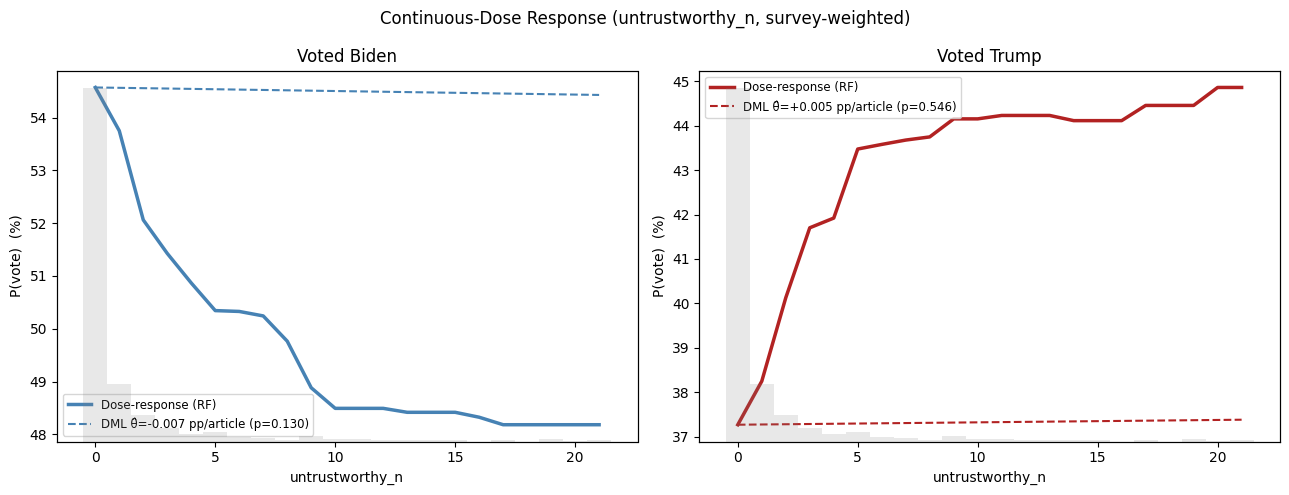

,theta,se,p,ci_lo,ci_hi
Voted for Biden,-0.000067,0.000045,0.129806,-0.000155,0.000020
Voted for Trump,0.000054,0.000089,0.545646,-0.000120,0.000227


In [210]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Continuous treatment
cont_treatment = "untrustworthy_n"
cont_cols = [cont_treatment, treatment] + list(outcomes.values()) + ["age", "female"] \
    + engineered_continuous + linear_features + categorical_covariates
df_cont = df[cont_cols].dropna().copy()

X_c = pd.get_dummies(
    df_cont[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates, drop_first=False, dtype=int,
).drop(columns=baselines_to_drop, errors="ignore").values
T_c = df_cont[cont_treatment].values.astype(float)
N_c = len(T_c)
Y_biden_c = df_cont["voted_biden_2020"].values
Y_trump_c = df_cont["voted_trump_2020"].values

raw = df.loc[df_cont.index, "weight_post"].fillna(1.0).values
lo, hi = np.percentile(raw, [5, 95])
sw_dml = np.clip(raw, lo, hi)
sw_dml = sw_dml / sw_dml.mean()

# DML
np.random.seed(42)
folds_c = np.array_split(np.random.permutation(N_c), 5)
T_hat = np.zeros(N_c)
Y_hat_b = np.zeros(N_c)
Y_hat_t = np.zeros(N_c)
for val in folds_c:
    tr = np.setdiff1d(np.arange(N_c), val)
    w = sw_dml[tr] / sw_dml[tr].mean()
    T_hat[val] = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=10,
                                       random_state=42, n_jobs=-1).fit(X_c[tr], T_c[tr], w).predict(X_c[val])
    Y_hat_b[val] = rf_fit(X_c[tr], Y_biden_c[tr], sw_dml[tr]).predict_proba(X_c[val])[:, 1]
    Y_hat_t[val] = rf_fit(X_c[tr], Y_trump_c[tr], sw_dml[tr]).predict_proba(X_c[val])[:, 1]

T_tilde = T_c - T_hat


def dml_estimate(T_tilde, Y, Y_hat, weights):
    w = weights / weights.mean()
    Y_tilde = Y - Y_hat
    theta = np.sum(w * T_tilde * Y_tilde) / np.sum(w * T_tilde ** 2)
    ic = w * T_tilde * (Y_tilde - theta * T_tilde) / np.mean(w * T_tilde ** 2)
    se = np.sqrt(np.mean(ic ** 2) / len(T_tilde))
    return dict(theta=theta, se=se, p=2 * (1 - stats.norm.cdf(abs(theta / se))),
                ci_lo=theta - 1.96 * se, ci_hi=theta + 1.96 * se)


res_b = dml_estimate(T_tilde, Y_biden_c, Y_hat_b, sw_dml)
res_t = dml_estimate(T_tilde, Y_trump_c, Y_hat_t, sw_dml)

# Dose-response curve
clf_b = rf_fit(np.column_stack([T_c, X_c]), Y_biden_c, sw_dml)
clf_t = rf_fit(np.column_stack([T_c, X_c]), Y_trump_c, sw_dml)
t_grid = np.arange(0, np.percentile(T_c, 95) + 1)
dr_b = np.array([clf_b.predict_proba(np.column_stack([np.full(N_c, t), X_c]))[:, 1].mean() for t in t_grid]) * 100
dr_t = np.array([clf_t.predict_proba(np.column_stack([np.full(N_c, t), X_c]))[:, 1].mean() for t in t_grid]) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, col, dr, res) in zip(axes, [
    ("Voted Biden", "steelblue", dr_b, res_b), ("Voted Trump", "firebrick", dr_t, res_t)]):
    ax.plot(t_grid, dr, color=col, lw=2.5, label="Dose-response (RF)")
    ax.plot(t_grid, dr[0] + res["theta"] * 100 * t_grid, color=col, lw=1.5, ls="--",
            label=f"DML θ̂={res['theta'] * 100:+.3f} pp/article (p={res['p']:.3f})")
    ax2 = ax.twinx()
    ax2.hist(T_c, bins=np.arange(0, t_grid.max() + 2) - 0.5, color="gray", alpha=0.18, density=True)
    ax2.set_yticks([])
    ax.set(xlabel="untrustworthy_n", ylabel="P(vote)  (%)", title=name)
    ax.legend(fontsize=8.5)
fig.suptitle("Continuous-Dose Response (untrustworthy_n, survey-weighted)")
fig.tight_layout()
plt.show()

pd.DataFrame({"Voted for Biden": res_b, "Voted for Trump": res_t}).T

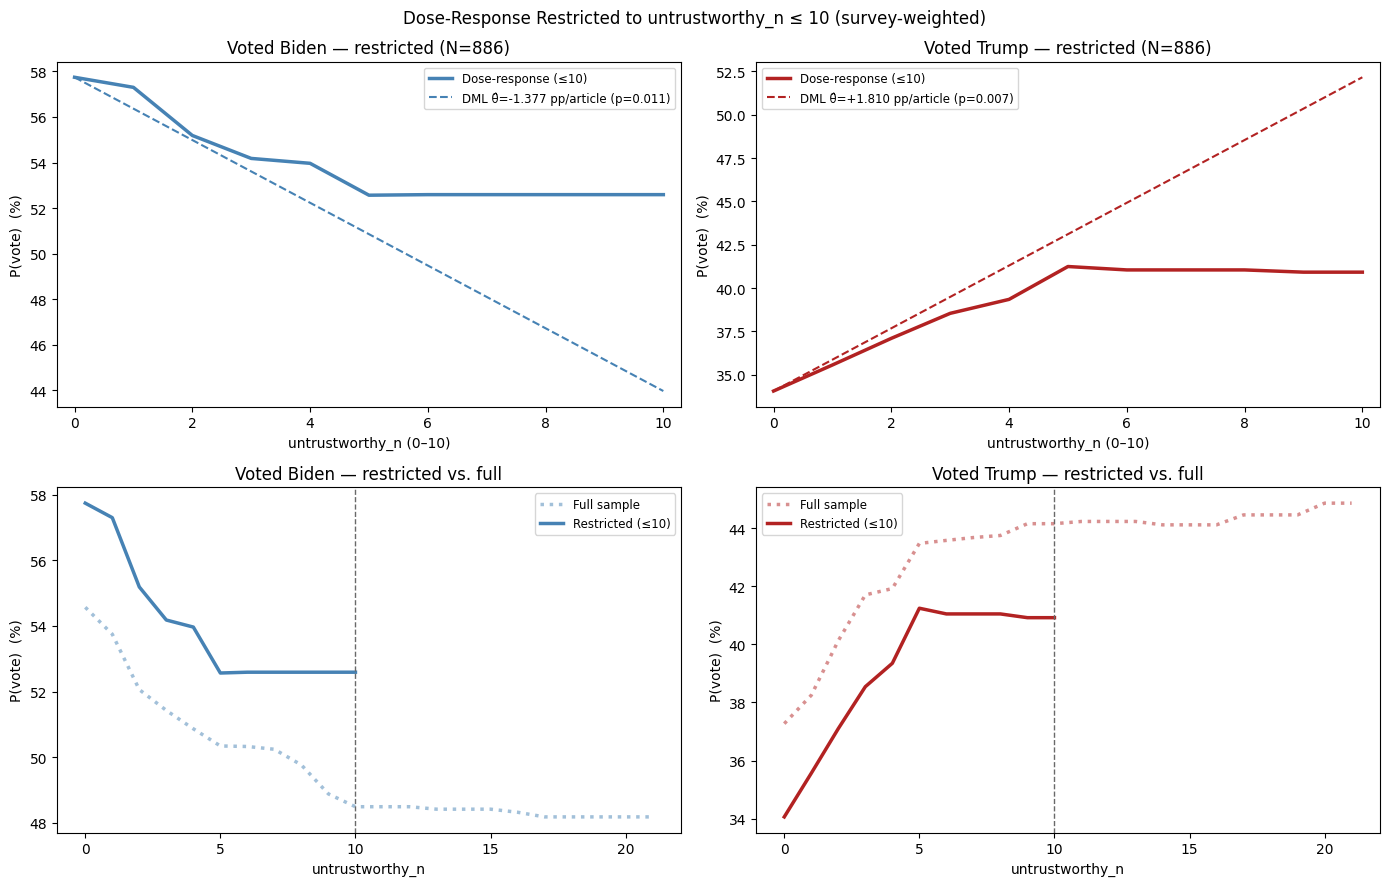

,binary ATE (pp),DML θ̂×gap (pp)
Voted for Biden,-5.236274,-3.799820
Voted for Trump,8.129363,4.993197


In [211]:
import matplotlib.pyplot as plt

MAX_T = 10
df_r = df_cont[df_cont[cont_treatment] <= MAX_T].copy()

X_r = pd.get_dummies(
    df_r[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates, drop_first=False, dtype=int,
).drop(columns=baselines_to_drop, errors="ignore").values
T_r = df_r[cont_treatment].values.astype(float)
N_r = len(T_r)
W_r = df_r[treatment].values.astype(int)
Y_b_r = df_r["voted_biden_2020"].values
Y_t_r = df_r["voted_trump_2020"].values

raw = df.loc[df_r.index, "weight_post"].fillna(1.0).values
lo, hi = np.percentile(raw, [5, 95])
sw_r = np.clip(raw, lo, hi)
sw_r = sw_r / sw_r.mean()

np.random.seed(42)
folds_r = np.array_split(np.random.permutation(N_r), 5)

# DML on the restricted sample
T_hat_r = np.zeros(N_r)
Y_hat_b_r = np.zeros(N_r)
Y_hat_t_r = np.zeros(N_r)
for val in folds_r:
    tr = np.setdiff1d(np.arange(N_r), val)
    w = sw_r[tr] / sw_r[tr].mean()
    T_hat_r[val] = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=10,
                                         random_state=42, n_jobs=-1).fit(X_r[tr], T_r[tr], w).predict(X_r[val])
    Y_hat_b_r[val] = rf_fit(X_r[tr], Y_b_r[tr], sw_r[tr]).predict_proba(X_r[val])[:, 1]
    Y_hat_t_r[val] = rf_fit(X_r[tr], Y_t_r[tr], sw_r[tr]).predict_proba(X_r[val])[:, 1]

res_b_r = dml_estimate(T_r - T_hat_r, Y_b_r, Y_hat_b_r, sw_r)
res_t_r = dml_estimate(T_r - T_hat_r, Y_t_r, Y_hat_t_r, sw_r)

# Restricted dose-response curve
clf_b_r = rf_fit(np.column_stack([T_r, X_r]), Y_b_r, sw_r)
clf_t_r = rf_fit(np.column_stack([T_r, X_r]), Y_t_r, sw_r)
t_grid_r = np.arange(0, MAX_T + 1, dtype=float)
dr_b_r = np.array([clf_b_r.predict_proba(np.column_stack([np.full(N_r, t), X_r]))[:, 1].mean() for t in t_grid_r]) * 100
dr_t_r = np.array([clf_t_r.predict_proba(np.column_stack([np.full(N_r, t), X_r]))[:, 1].mean() for t in t_grid_r]) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for j, (name, col, dr_r, res_r, dr_full) in enumerate([
    ("Voted Biden", "steelblue", dr_b_r, res_b_r, dr_b),
    ("Voted Trump", "firebrick", dr_t_r, res_t_r, dr_t)]):
    ax = axes[0, j]
    ax.plot(t_grid_r, dr_r, color=col, lw=2.5, label=f"Dose-response (≤{MAX_T})")
    ax.plot(t_grid_r, dr_r[0] + res_r["theta"] * 100 * t_grid_r, color=col, lw=1.5, ls="--",
            label=f"DML θ̂={res_r['theta'] * 100:+.3f} pp/article (p={res_r['p']:.3f})")
    ax.set(xlim=(-0.3, MAX_T + 0.3), xlabel=f"untrustworthy_n (0–{MAX_T})",
           ylabel="P(vote)  (%)", title=f"{name} — restricted (N={N_r})")
    ax.legend(fontsize=8.5)

    ax = axes[1, j]
    ax.plot(np.arange(len(dr_full)), dr_full, color=col, lw=2.5, alpha=0.5, ls=":", label="Full sample")
    ax.plot(t_grid_r, dr_r, color=col, lw=2.5, label=f"Restricted (≤{MAX_T})")
    ax.axvline(MAX_T, color="dimgray", ls="--", lw=1)
    ax.set(xlabel="untrustworthy_n", ylabel="P(vote)  (%)", title=f"{name} — restricted vs. full")
    ax.legend(fontsize=8.5)
fig.suptitle(f"Dose-Response Restricted to untrustworthy_n ≤ {MAX_T} (survey-weighted)")
fig.tight_layout()
plt.show()


def aipw_ate(W, Y, e, mu1, mu0, weights):
    e = np.clip(e, 0.05, 0.95)
    psi = (mu1 - mu0) + W * (Y - mu1) / e - (1 - W) * (Y - mu0) / (1 - e)
    ate = np.average(psi, weights=weights)
    se = np.sqrt(np.sum((weights * (psi - ate)) ** 2) / len(psi) ** 2)
    return dict(ate=ate, se=se, p=2 * (1 - stats.norm.cdf(abs(ate / se))),
                ci_lo=ate - 1.96 * se, ci_hi=ate + 1.96 * se)


# Binary AIPW
e_r = np.zeros(N_r)
mu1_b = np.zeros(N_r); mu0_b = np.zeros(N_r)
mu1_t = np.zeros(N_r); mu0_t = np.zeros(N_r)
for val in folds_r:
    tr = np.setdiff1d(np.arange(N_r), val)
    w, t, c = sw_r[tr], W_r[tr] == 1, W_r[tr] == 0
    e_r[val] = rf_fit(X_r[tr], W_r[tr], w).predict_proba(X_r[val])[:, 1]
    mu1_b[val] = rf_fit(X_r[tr][t], Y_b_r[tr][t], w[t]).predict_proba(X_r[val])[:, 1]
    mu0_b[val] = rf_fit(X_r[tr][c], Y_b_r[tr][c], w[c]).predict_proba(X_r[val])[:, 1]
    mu1_t[val] = rf_fit(X_r[tr][t], Y_t_r[tr][t], w[t]).predict_proba(X_r[val])[:, 1]
    mu0_t[val] = rf_fit(X_r[tr][c], Y_t_r[tr][c], w[c]).predict_proba(X_r[val])[:, 1]

bin_b_r = aipw_ate(W_r, Y_b_r, e_r, mu1_b, mu0_b, sw_r)
bin_t_r = aipw_ate(W_r, Y_t_r, e_r, mu1_t, mu0_t, sw_r)
gap = T_r[W_r == 1].mean() - T_r[W_r == 0].mean()

pd.DataFrame({
    "Voted for Biden": {"binary ATE (pp)": bin_b_r["ate"] * 100, "DML θ̂×gap (pp)": res_b_r["theta"] * 100 * gap},
    "Voted for Trump": {"binary ATE (pp)": bin_t_r["ate"] * 100, "DML θ̂×gap (pp)": res_t_r["theta"] * 100 * gap},
}).T

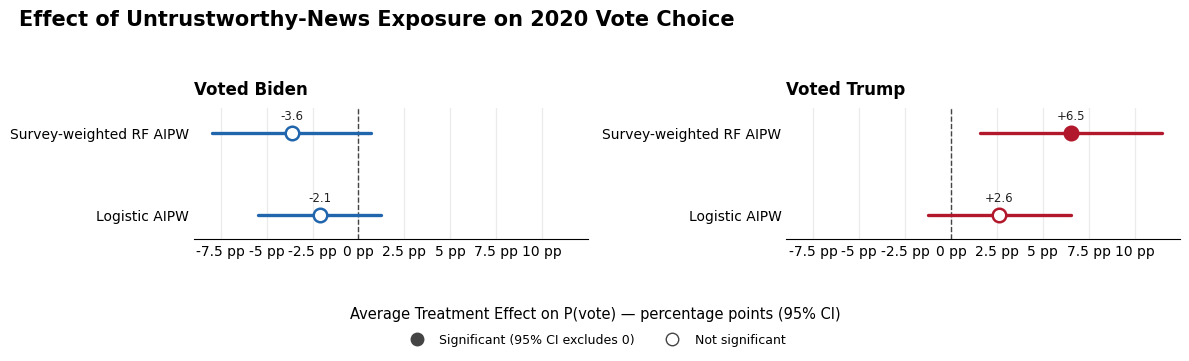

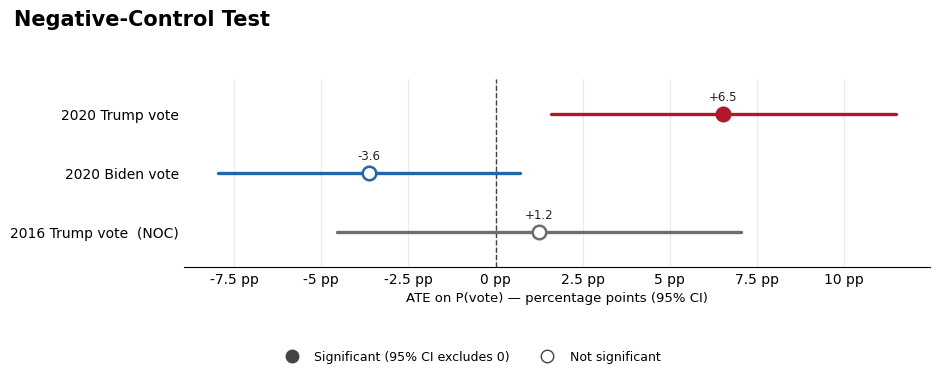

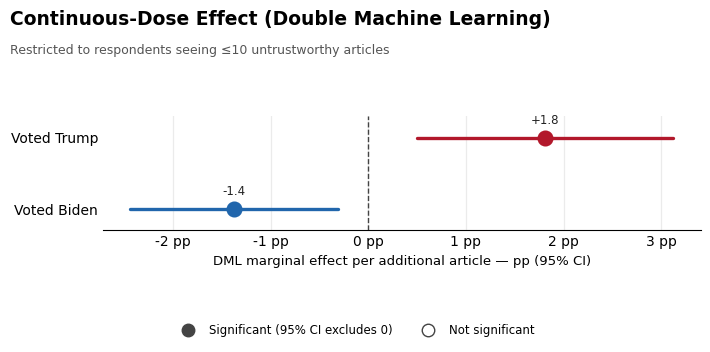

In [212]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

BIDEN_C, TRUMP_C, NOC_C = "#2166AC", "#B2182B", "#6E6E6E"

sig_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#444", markeredgecolor="#444",
           markersize=9, label="Significant (95% CI excludes 0)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="white", markeredgecolor="#444",
           markersize=9, label="Not significant"),
]


def forest_panel(ax, rows, title="", scale=100):
    y = np.arange(len(rows))[::-1]
    for yi, r in zip(y, rows):
        est, lo, hi = r["est"] * scale, r["lo"] * scale, r["hi"] * scale
        sig = not (r["lo"] < 0 < r["hi"])
        ax.plot([lo, hi], [yi, yi], color=r["color"], lw=2.4, solid_capstyle="round", zorder=2)
        ax.scatter([est], [yi], s=95, zorder=3, edgecolor=r["color"], linewidth=1.8,
                   facecolor=r["color"] if sig else "white")
        ax.annotate(f"{est:+.1f}", (est, yi), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=8.5, color="#222222")
    ax.axvline(0, color="#444444", ls="--", lw=1, zorder=1)
    ax.set_yticks(y)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=10)
    if title:
        ax.set_title(title, fontsize=12, fontweight="bold", loc="left", pad=10)
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%g pp"))
    ax.grid(axis="x", color="0.92", lw=0.9)
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    ax.margins(y=0.30)


def row(label, res, color):
    return dict(label=label, est=res["ate"], lo=res["ci_lo"], hi=res["ci_hi"], color=color)


# Binary ATE
fig, axes = plt.subplots(1, 2, figsize=(12, 3.0), sharex=True)
forest_panel(axes[0], [row("Survey-weighted RF AIPW", rf_aipw_results["Voted for Biden"], BIDEN_C),
                       row("Logistic AIPW", param_aipw_results["Voted for Biden"], BIDEN_C)], "Voted Biden")
forest_panel(axes[1], [row("Survey-weighted RF AIPW", rf_aipw_results["Voted for Trump"], TRUMP_C),
                       row("Logistic AIPW", param_aipw_results["Voted for Trump"], TRUMP_C)], "Voted Trump")
fig.supxlabel("Average Treatment Effect on P(vote) — percentage points (95% CI)", fontsize=10.5, y=0.0)
fig.suptitle("Effect of Untrustworthy-News Exposure on 2020 Vote Choice",
             fontsize=15, fontweight="bold", x=0.02, ha="left", y=1.04)
fig.legend(handles=sig_legend, loc="lower center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()

# Negative-control test
nc_rows = [
    row("2020 Trump vote", rf_aipw_results["Voted for Trump"], TRUMP_C),
    row("2020 Biden vote", rf_aipw_results["Voted for Biden"], BIDEN_C),
    dict(label="2016 Trump vote  (NOC)", est=ate_noc_rf, lo=ci_lo_noc, hi=ci_hi_noc, color=NOC_C),
]
fig, ax = plt.subplots(figsize=(9.5, 3.2))
forest_panel(ax, nc_rows)
ax.set_xlabel("ATE on P(vote) — percentage points (95% CI)", fontsize=9.5)
fig.suptitle("Negative-Control Test", fontsize=15, fontweight="bold", x=0.02, ha="left", y=1.02)
fig.legend(handles=sig_legend, loc="lower center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

# Continuous-dose DML
dml_rows = [
    dict(label="Voted Trump", est=res_t_r["theta"], lo=res_t_r["ci_lo"], hi=res_t_r["ci_hi"], color=TRUMP_C),
    dict(label="Voted Biden", est=res_b_r["theta"], lo=res_b_r["ci_lo"], hi=res_b_r["ci_hi"], color=BIDEN_C),
]
fig, ax = plt.subplots(figsize=(7.2, 2.6))
forest_panel(ax, dml_rows)
ax.set_xlabel("DML marginal effect per additional article — pp (95% CI)", fontsize=9.5)
fig.suptitle("Continuous-Dose Effect (Double Machine Learning)",
             fontsize=13.5, fontweight="bold", x=0.02, ha="left", y=1.12)
fig.text(0.02, 0.95, "Restricted to respondents seeing ≤10 untrustworthy articles", fontsize=9, color="#555555")
fig.legend(handles=sig_legend, loc="lower center", ncol=2, frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, -0.18))
fig.tight_layout(rect=[0, 0.07, 1, 0.90])
plt.show()

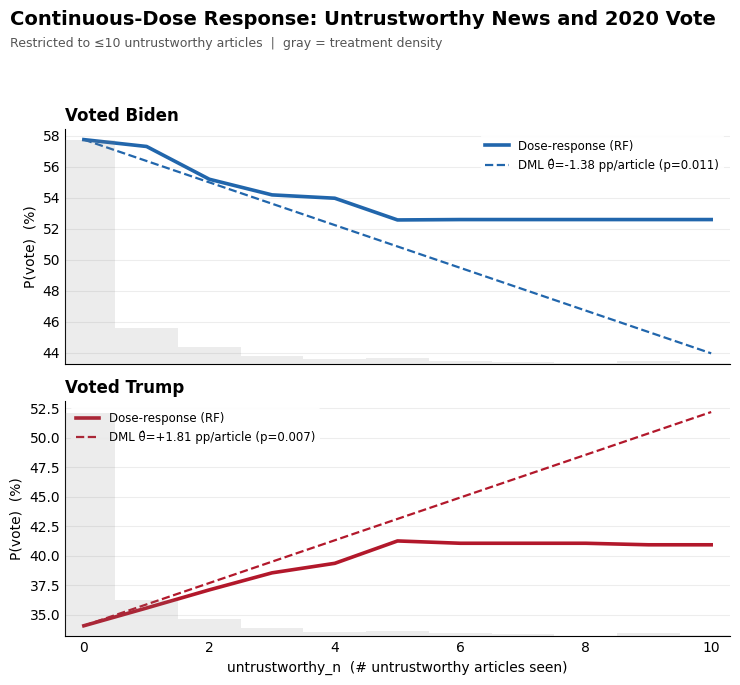

In [206]:
import matplotlib.pyplot as plt

# Restricted dose-response, stacked vertically with a shared x-axis
fig, axes = plt.subplots(2, 1, figsize=(7.5, 6.8), sharex=True)
for name, dr, res, col, ax in [("Voted Biden", dr_b_r, res_b_r, BIDEN_C, axes[0]),
                               ("Voted Trump", dr_t_r, res_t_r, TRUMP_C, axes[1])]:
    axd = ax.twinx()
    axd.hist(T_r, bins=np.arange(0, MAX_T + 2) - 0.5, color="gray", alpha=0.15, density=True, zorder=0)
    axd.set_yticks([])
    for sp in axd.spines.values():
        sp.set_visible(False)

    ax.plot(t_grid_r, dr, color=col, lw=2.6, zorder=3, label="Dose-response (RF)")
    ax.plot(t_grid_r, dr[0] + res["theta"] * 100 * t_grid_r, color=col, lw=1.6, ls="--", zorder=2,
            label=f"DML θ̂={res['theta'] * 100:+.2f} pp/article (p={res['p']:.3f})")
    ax.set(xlim=(-0.3, MAX_T + 0.3), ylabel="P(vote)  (%)")
    ax.set_title(name, fontsize=12, fontweight="bold", loc="left", pad=6)
    ax.grid(axis="y", color="0.93", lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    ax.legend(fontsize=8.5, loc="best", framealpha=0.9, edgecolor="none")

axes[1].set_xlabel("untrustworthy_n  (# untrustworthy articles seen)", fontsize=10)
fig.suptitle("Continuous-Dose Response: Untrustworthy News and 2020 Vote",
             fontsize=14, fontweight="bold", x=0.02, ha="left", y=1.0)
fig.text(0.02, 0.945, "Restricted to ≤10 untrustworthy articles  |  gray = treatment density",
         fontsize=9, color="#555555")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

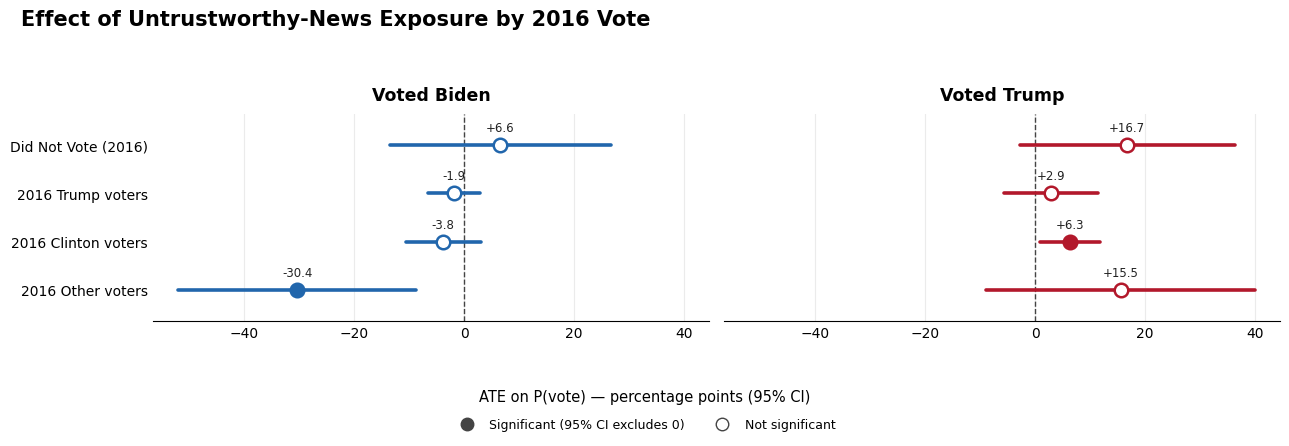

In [213]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

subgroups = ["Did Not Vote (2016)", "2016 Trump voters", "2016 Clinton voters", "2016 Other voters"]
biden = [(6.57, -13.54, 26.68), (-1.91, -6.63, 2.81), (-3.84, -10.66, 2.98), (-30.36, -52.02, -8.70)]
trump = [(16.73, -2.79, 36.25), (2.87, -5.66, 11.40), (6.35, 0.94, 11.76), (15.52, -8.88, 39.92)]


def subgroup_panel(ax, data, color, title, labels=None):
    y = np.arange(len(data))[::-1]
    for yi, (est, lo, hi) in zip(y, data):
        sig = not (lo < 0 < hi)
        ax.plot([lo, hi], [yi, yi], color=color, lw=2.6, solid_capstyle="round", zorder=2)
        ax.scatter([est], [yi], s=95, zorder=3, edgecolor=color, linewidth=1.8,
                   facecolor=color if sig else "white")
        ax.annotate(f"{est:+.1f}", (est, yi), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=8.5, color="#222222")
    ax.axvline(0, color="#444444", ls="--", lw=1, zorder=1)
    ax.set_yticks(y)
    ax.set_yticklabels(labels if labels is not None else [""] * len(data), fontsize=10)
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=10)
    ax.grid(axis="x", color="0.92", lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    ax.margins(y=0.22)


fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharex=True)
subgroup_panel(axes[0], biden, "#2166AC", "Voted Biden", labels=subgroups)
subgroup_panel(axes[1], trump, "#B2182B", "Voted Trump")
fig.supxlabel("ATE on P(vote) — percentage points (95% CI)", fontsize=10.5, y=0.0)
fig.suptitle("Effect of Untrustworthy-News Exposure by 2016 Vote",
             fontsize=15, fontweight="bold", x=0.02, ha="left", y=1.04)
fig.legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#444", markeredgecolor="#444",
           markersize=9, label="Significant (95% CI excludes 0)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="white", markeredgecolor="#444",
           markersize=9, label="Not significant"),
], loc="lower center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.10))
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()